In [1]:
import numpy as np

import os
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter
import struct
import jax.numpy as jnp
import jax
import seaborn
import scienceplots

plt.style.use(['science','notebook'])


jax.config.update("jax_enable_x64", True)

In [2]:
%%html
<style>
.jp-Notebook {
  --jp-notebook-max-width: 98%;
}</style>

In [3]:
@jax.jit
def Energy_spectra(x):
  return jnp.histogram(k.ravel(),bins = shells,weights = x.ravel())

In [4]:
pi = jnp.pi
N = 2**9

L = 2*pi
dx = L/N

nu = 1e-3
kvals = np.arange(0,N//2+1)

# ----------------------------------------
# Spectral Grid Setup (Memory-Efficient)
# ----------------------------------------

kx , ky , kz  = np.meshgrid(jnp.fft.fftfreq(N, dx)*(2*pi),jnp.fft.fftfreq(N, dx)*(2*pi), jnp.fft.rfftfreq(N, dx)*(2*pi),indexing= 'ij')

k_vec = np.stack([kx,ky,kz])

# k_sq = (k_vec[0]**2 + k_vec[1]**2 + k_vec[2]**2)

# k = np.sqrt(k_sq)

# derivative_operator = 1j*k_vec

# shells = np.arange(-0.5, N//2 + 1 , 1.)
# shells[0] = 0.
# # ----------------------------------------
# # Dealiasing and Projection Utilities
# # ----------------------------------------

# alias_mask = (abs(k_vec[0])<=N//3)*(abs(k_vec[1])<=N//3)*(abs(k_vec[2])<=N//3)

# k_over_k_sq = np.where(k_sq == 0 , 0 ,  k_vec/k_sq)*alias_mask

# kint = np.clip(np.round(k,0).astype(int),None,N//2)

normalize = np.where((k_vec[2] == 0) + (k_vec[2] == N//2) , 1/N**6,2/N**6)

# Average Dissipation: $\langle \epsilon\rangle$ = 2 $\nu S_{ij} S_{ij}$

In [5]:
# HOMOGENEOUS

# avg_dissp = np.array([np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p0.npz')['avg_dissp']])

# avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p03.npz')['avg_dissp']],axis =0)
 
# avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p05.npz')['avg_dissp']],axis =0)

# avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p07.npz')['avg_dissp']],axis =0)

# avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p1.npz')['avg_dissp']],axis =0)

# avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p3.npz')['avg_dissp']],axis =0)

# avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p5.npz')['avg_dissp']],axis =0)


# Fractal

avg_dissp = np.array([np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Fractal_D3p0.npz')['avg_dissp']])

avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Fractal_D2p98.npz')['avg_dissp']],axis =0)

avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Fractal_D2p95.npz')['avg_dissp']],axis =0)

avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Fractal_D2p90.npz')['avg_dissp']],axis =0)

avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Fractal_D2p80.npz')['avg_dissp']],axis =0)

In [6]:
print(avg_dissp)

[0.76246217 0.73475689 0.82955253 0.77762812 0.87071721]


In [7]:
# # HOMOGENEOUS

# E_k_arr = np.array([np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Spectra_Decimated_Homogeneous_P0p0.npz')['E_k']])

# E_k_arr  = np.append(E_k_arr , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Spectra_Decimated_Homogeneous_P0p03.npz')['E_k']],axis =0)
 
# E_k_arr  = np.append(E_k_arr , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Spectra_Decimated_Homogeneous_P0p05.npz')['E_k']],axis =0)

# E_k_arr  = np.append(E_k_arr , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Spectra_Decimated_Homogeneous_P0p07.npz')['E_k']],axis =0)


# E_k_arr  = np.append(E_k_arr , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Spectra_Decimated_Homogeneous_P0p1.npz')['E_k']],axis =0)

# E_k_arr  = np.append(E_k_arr , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Spectra_Decimated_Homogeneous_P0p3.npz')['E_k']],axis =0)

# E_k_arr  = np.append(E_k_arr , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Spectra_Decimated_Homogeneous_P0p5.npz')['E_k']],axis =0)



# Fractal


E_k_arr_fractal = np.array([np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Spectra_Decimated_Fractal_D3p00.npz')['E_k']])

E_k_arr_fractal  = np.append(E_k_arr_fractal , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Spectra_Decimated_Fractal_D2p98.npz')['E_k']],axis =0)
 
E_k_arr_fractal  = np.append(E_k_arr_fractal , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Spectra_Decimated_Fractal_D2p95.npz')['E_k']],axis =0)

E_k_arr_fractal  = np.append(E_k_arr_fractal , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Spectra_Decimated_Fractal_D2p90.npz')['E_k']],axis =0)

E_k_arr_fractal  = np.append(E_k_arr_fractal , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Spectra_Decimated_Fractal_D2p80.npz')['E_k']],axis =0)


# Kinetic Energy = $\sum_k E(k)$ 

In [8]:
KE = np.zeros(5)

for i in range(5):
    
    print(np.sum(E_k_arr_fractal[i,:]))

    KE[i] = np.sum(E_k_arr_fractal[i,:])

2.3125351385932844
2.343190471218578
2.4465296873810205
2.7642949914624704
2.934085486681289


# $U_{rms}$

In [9]:
u_rms = np.sqrt(2*KE/3)
u_rms

array([1.24164814, 1.24985078, 1.27711385, 1.35752102, 1.39859107])

# Integral Length: $ L_{int} = \frac{\pi}{2 u_{rms}^2} \int_0^\infty k^{-1}E(k)dk $

In [10]:
L_int = np.zeros(5)

for i in range(5):

    li = (np.pi/2)*(1/u_rms[i]**2)*np.sum(E_k_arr_fractal[i,1:]/kvals[1:])  # dk = 1
    
    print(li)
    
    L_int[i] = li

1.1972391448578643
1.1468718894253656
1.1180636725550663
1.0845851806170805
0.9830272409386134


# Taylor Reynolds Number : $Re_\lambda = u_{rms} \lambda / \nu$ 

# $u_{rms} = \sqrt{2/3 (KE)}$

# $\lambda = \sqrt{\frac{15 \nu}{\epsilon}} u_{rms}$ 

In [18]:
sxx = np.array([np.mean(np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Strain_field_Sxx/Strain_XX_field_Homogeneous_P0p0.npz')['sxx']**2)])

sxx = np.append(sxx , np.array([np.mean(np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Strain_field_Sxx/Strain_XX_field_Homogeneous_P0p03.npz')['sxx']**2)]), axis =0)

sxx = np.append(sxx , np.array([np.mean(np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Strain_field_Sxx/Strain_XX_field_Homogeneous_P0p05.npz')['sxx']**2)]), axis =0)

sxx = np.append(sxx , np.array([np.mean(np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Strain_field_Sxx/Strain_XX_field_Homogeneous_P0p07.npz')['sxx']**2)]), axis =0)

sxx = np.append(sxx , np.array([np.mean(np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Strain_field_Sxx/Strain_XX_field_Homogeneous_P0p1.npz')['sxx']**2)]), axis =0)

sxx = np.append(sxx , np.array([np.mean(np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Strain_field_Sxx/Strain_XX_field_Homogeneous_P0p3.npz')['sxx']**2)]), axis =0)

sxx = np.append(sxx , np.array([np.mean(np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Strain_field_Sxx/Strain_XX_field_Homogeneous_P0p5.npz')['sxx']**2)]), axis =0)


In [19]:
# sxx = np.array([np.mean(np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Strain_field_Sxx/Strain_XX_field_Homogeneous_P0p0.npz')['sxx']**2)])

# sxx = np.append(sxx , np.array([np.mean(np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Strain_field_Sxx/Strain_XX_field_Fractal_D_2p98.npz')['sxx']**2)]), axis =0)

# sxx = np.append(sxx , np.array([np.mean(np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Strain_field_Sxx/Strain_XX_field_Fractal_D_2p95.npz')['sxx']**2)]), axis =0)

# sxx = np.append(sxx , np.array([np.mean(np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Strain_field_Sxx/Strain_XX_field_Fractal_D_2p90.npz')['sxx']**2)]), axis =0)

# sxx = np.append(sxx , np.array([np.mean(np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Strain_field_Sxx/Strain_XX_field_Fractal_D_2p80.npz')['sxx']**2)]), axis =0)


In [20]:
nu = 1e-3

Lambda =  u_rms*np.sqrt(1/sxx)

Re_Lambda =  u_rms*Lambda/nu

In [21]:
# lambda_Taylor_1 = np.sqrt(15*(nu/avg_dissp))*u_rms

# lambda_Taylor_2 = np.sqrt(10*(nu/avg_dissp)*KE)

# lambda_Taylor_1

# lambda_Taylor_2

In [22]:
Re_Lambda

array([216.81787252, 224.5353783 , 229.80352605, 234.22053352,
       238.44846827, 247.94666145, 532.04146507])

# Saving the Data

In [23]:
# np.savetxt('OurData/Decimation_P0p0_Re_epsilon_E_L.out', [Re_Lambda[0], avg_dissp[0], KE[0], L_int[0]])
# np.savetxt('OurData/Decimation_P0p03_Re_epsilon_E_L.out', [Re_Lambda[1], avg_dissp[1], KE[1], L_int[1]])
# np.savetxt('OurData/Decimation_P0p05_Re_epsilon_E_L.out', [Re_Lambda[2], avg_dissp[2], KE[2], L_int[2]])
# np.savetxt('OurData/Decimation_P0p07_Re_epsilon_E_L.out', [Re_Lambda[3], avg_dissp[3], KE[3], L_int[3]])
# np.savetxt('OurData/Decimation_P0p1_Re_epsilon_E_L.out', [Re_Lambda[4], avg_dissp[4], KE[4], L_int[4]])
# np.savetxt('OurData/Decimation_P0p3_Re_epsilon_E_L.out', [Re_Lambda[5], avg_dissp[5], KE[5], L_int[5]])
# np.savetxt('OurData/Decimation_P0p5_Re_epsilon_E_L.out', [Re_Lambda[6], avg_dissp[6], KE[6], L_int[6]])

# Estimating Kolmogorov Constant

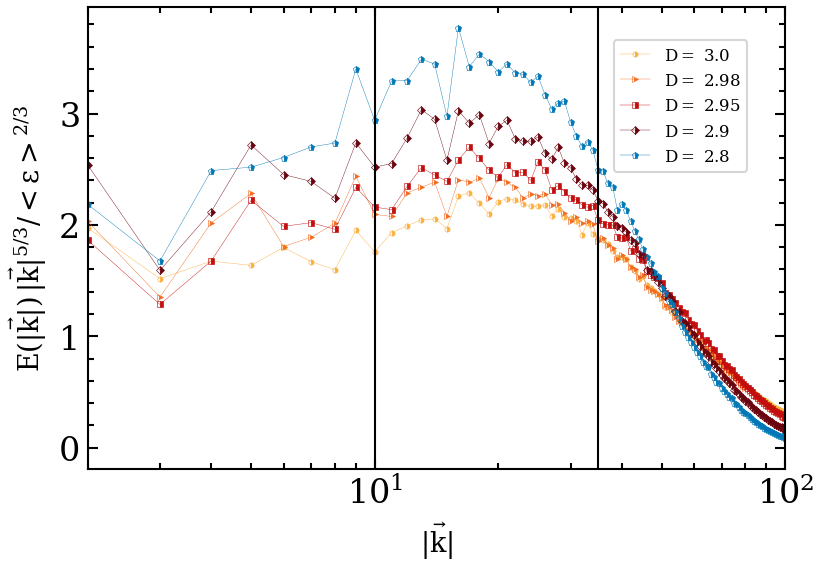

In [12]:
# ---------- Style setup ----------
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'axes.linewidth': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'legend.frameon': False,
    'mathtext.default': 'regular',
})


fig, ax = plt.subplots(1,1,figsize=(6,4), dpi=150)

ax.set_xlabel(r'$|\vec k|$', labelpad=5)
ax.set_ylabel(r'$E(|\vec k|) \, |\vec k|^{5/3}/<\epsilon>^{2/3}$', labelpad=5)

# ---------- Data ----------
labels = [0, 3, 5, 7, 10, 30, 50]

colors = ['#f9c74f', '#fbb040', '#f26b21', '#c30e0e','#6a040f','#0077b6',"#01263d"]

Dim = [3.0 , 2.98 , 2.95 , 2.90 , 2.8]

markers = ['o', 's', 'D', '*', '^', '.', '<']

alphas = [0.00, 0.03, 0.05, 0.07, 0.10, 0.30, 0.50]

markers = ['o','>' ,'s', 'D', 'p', 'h', '*']
ms =  [2.5,3,2.5,2.5,3,3,3.4]

# ---------- Plot curves ----------
for i in range(0,5):
    ax.plot(
        kvals[2:N//3+2],
        (kvals[2:N//3+2]**(5/3)*E_k_arr_fractal[i, 2:N//3+2])/(avg_dissp[i])**(2/3),
        marker=markers[i],
        markersize= ms[i],
        linewidth=0.2,
        color=colors[i+1],
        fillstyle='right',
        label=fr'$D = $ {Dim[i]}',
        markeredgewidth=0.3)


# ---------- Limits, scales, and grid ----------

ax.set_xscale('log')
ax.set_xlim(2,100)

ax.axvline(10 , lw = 1, c = 'black')
ax.axvline(35, lw = 1, c = 'black')




# ---------- Legend ----------
ax.legend(loc='center',bbox_to_anchor=(0.85, 0.785),  handlelength=1.8,frameon=True,prop={'size': 8})

plt.show()

In [18]:
C_kol = np.zeros(5)
C_kol_error = np.zeros(5)

for i in range(5):
    
    C_kol_dumm = (kvals[2:N//3+2]**(5/3)*E_k_arr_fractal[i, 2:N//3+2])/(avg_dissp[i])**(2/3)

    C_kol[i] = np.mean(C_kol_dumm[5:20])

    C_kol_error[i] = np.std(C_kol_dumm[5:20])


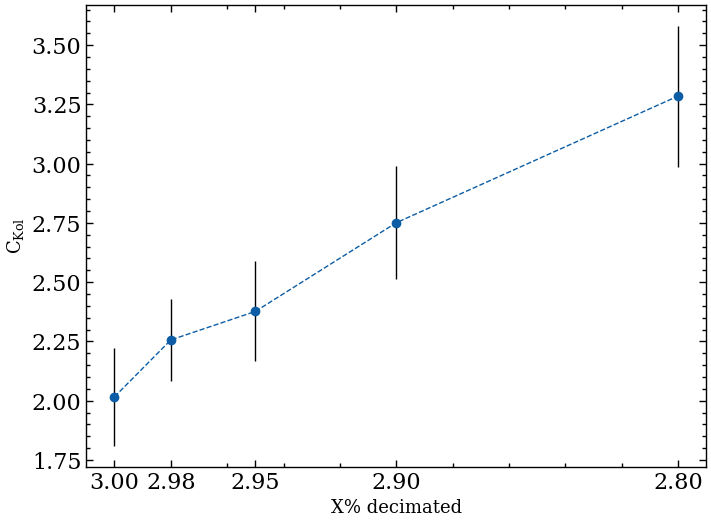

In [19]:
plt.errorbar(Dim , C_kol , C_kol_error, fmt = 'o--' , ecolor = 'black'  , lw = 1)
plt.xlabel("X% decimated")
plt.ylabel(r"$C_{Kol}$")
plt.xticks([3,2.98,2.95,2.9,2.8])
plt.gca().invert_xaxis()

plt.show()

In [17]:
np.savetxt("Fractal_Decimation_Vs_C_Kol.out" , jnp.array([Dim , C_kol, C_kol_error]).T)

# Average Dissipation Vs. Decimation

In [19]:
non_dim_epsilon_homogeneous = (avg_dissp*L_int)/u_rms**3

alphas = [0.00, 0.03, 0.05, 0.07, 0.10, 0.30, 0.50]

In [28]:
non_dim_epsilon_Fractal = (avg_dissp*L_int)/u_rms**3
Dim = [3.0 , 2.98 , 2.95 , 2.90 , 2.8]

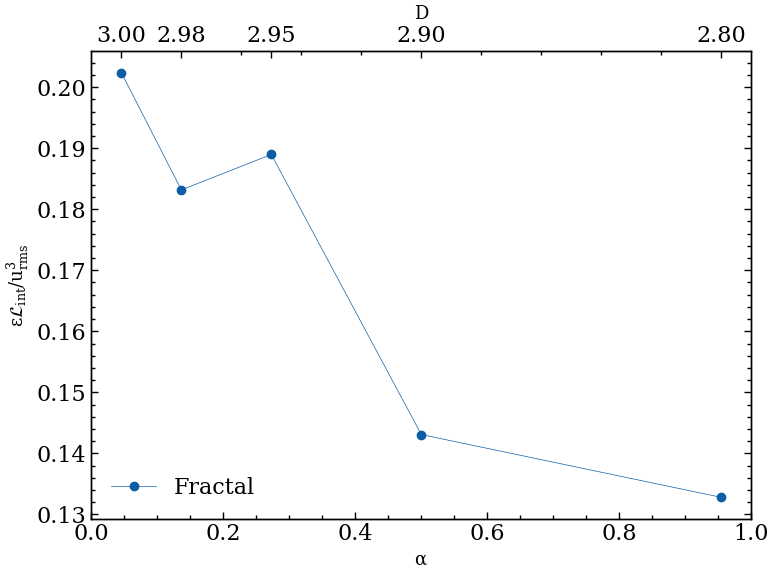

In [24]:
fig, ax = plt.subplots()

# # Bottom x-axis
# ax.plot(alphas, non_dim_epsilon_homogeneous, 'o-', lw=0.5, color ='black', label = 'Homogeneous')
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$\epsilon \mathcal{L}_{int}/ u_{rms}^3$')
# plt.legend(loc = 'lower center')

# Top x-axis
ax_top = ax.twiny()
ax_top.plot(Dim, non_dim_epsilon_Fractal, 'o-', lw=0.5, label = 'Fractal')
ax_top.set_xlabel(r'$D$')
plt.legend(loc = 'lower left')
plt.xticks([2.8,2.9,2.95,2.98,3.0])
plt.tight_layout()
plt.gca().invert_xaxis()

plt.show()
